In [18]:
# =====================================================
# ECO VISION AI - INFERENCIA
# =====================================================

# Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Librerías
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# =====================================================
# CONFIGURACIÓN
# =====================================================

RUTA_MODELO = "/content/drive/MyDrive/EcoVisionAI/Modelos/EcoVisionAI_ResNet50.pth"

CLASES = [
    "Basura",
    "Bateria",
    "Biologica",
    "Carton",
    "Metal",
    "Papel",
    "Plastico",
    "Vidrio Cafe",
    "Vidrio Verde",
    "Vidrio blanco"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [20]:
# =====================================================
# CARGAR MODELO RESNET50
# =====================================================

# Crear la arquitectura ResNet50
model = models.resnet50(weights=None)

# Cambiar la última capa para las 10 clases
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(CLASES))

# Cargar los pesos entrenados
model.load_state_dict(torch.load(RUTA_MODELO, map_location=device))

# Enviar a GPU
model = model.to(device)

# Modo evaluación
model.eval()

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


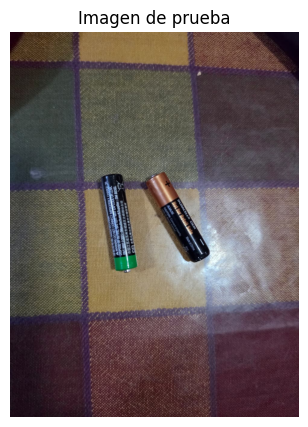

RESULTADO DE CLASIFICACIÓN

Clase detectada: Carton
Confianza: 43.86%

Estado: ❌ No pude reconocer correctamente la imagen.
Intenta subir una imagen más clara.

TOP 5 PREDICCIONES
1. Carton          43.86%
2. Papel           14.11%
3. Vidrio blanco   13.92%
4. Basura          11.21%
5. Metal           5.79%


In [21]:
# =====================================================
# TRANSFORMACIONES (LAS MISMAS DEL ENTRENAMIENTO)
# =====================================================

transformaciones = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =====================================================
# CONSEJOS ECOLOGICOS
# =====================================================

consejos = {
    "Basura": "Este residuo puede no ser reciclable. Intenta reducir su consumo y separar correctamente.",

    "Bateria": "No la tires a la basura común. Llévala a un punto de recolección especializado.",

    "Biologica": "Los residuos orgánicos pueden aprovecharse mediante composta si se separan correctamente.",

    "Carton": "Puedes reciclarlo. Retira restos de comida y evita mojarlo.",

    "Metal": "Las latas y metales pueden reciclarse. Límpialos antes de depositarlos.",

    "Papel": "Separa el papel limpio para facilitar su reciclaje.",

    "Plastico": "Limpia los envases y sepáralos correctamente para reciclaje.",

    "Vidrio Cafe": "El vidrio café puede reciclarse. Sepáralo del resto de materiales.",

    "Vidrio Verde": "El vidrio verde puede reciclarse. Deposítalo en un contenedor adecuado.",

    "Vidrio blanco": "El vidrio transparente puede reciclarse. Evita mezclarlo con otros residuos."
}


# =====================================================
# IMAGEN DE PRUEBA
# =====================================================

RUTA_IMAGEN = "/content/drive/MyDrive/EcoVisionAI/ImagenesPrueba/imagen.jpeg"

imagen = Image.open(RUTA_IMAGEN).convert("RGB")


plt.figure(figsize=(5,5))
plt.imshow(imagen)
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()


# =====================================================
# PREDICCION
# =====================================================

imagen_tensor = transformaciones(imagen)
imagen_tensor = imagen_tensor.unsqueeze(0).to(device)


with torch.no_grad():
    salida = model(imagen_tensor)
    probabilidades = F.softmax(salida, dim=1)


# Predicción principal
confianza, indice = torch.max(probabilidades, 1)

clase_predicha = CLASES[indice.item()]
confianza_valor = confianza.item() * 100


# =====================================================
# INTERPRETACION
# =====================================================

print("=" * 60)
print("RESULTADO DE CLASIFICACIÓN")
print("=" * 60)

print(f"\nClase detectada: {clase_predicha}")
print(f"Confianza: {confianza_valor:.2f}%\n")


if confianza_valor >= 80:

    print("Estado: ✅ Residuo identificado correctamente")

    if clase_predicha in consejos:
        print("\nConsejo:")
        print(consejos[clase_predicha])


elif confianza_valor >= 50:

    print("Estado: ⚠️ Predicción con baja seguridad")
    print("Puede que el residuo no esté claramente visible.")


else:

    print("Estado: ❌ No pude reconocer correctamente la imagen.")
    print("Intenta subir una imagen más clara.")



# =====================================================
# TOP 5 PREDICCIONES
# =====================================================

top5_probabilidades, top5_indices = torch.topk(probabilidades, 5)


print("\n" + "=" * 60)
print("TOP 5 PREDICCIONES")
print("=" * 60)


for i in range(5):
    clase = CLASES[top5_indices[0][i].item()]
    porcentaje = top5_probabilidades[0][i].item() * 100

    print(f"{i+1}. {clase:<15} {porcentaje:.2f}%")

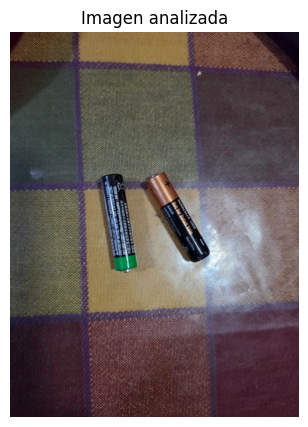

♻️ RESULTADO ECOVISIONAI

Residuo detectado: Carton
Confianza: 43.86%

Estado: ❌ No estoy seguro del residuo
Intenta subir una imagen más clara.

TOP 5 OPCIONES
1. Carton          43.86%
2. Papel           14.11%
3. Vidrio blanco   13.92%
4. Basura          11.21%
5. Metal           5.79%


{'clase': 'Carton',
 'confianza': 43.85729730129242,
 'probabilidades': tensor([[0.1121, 0.0331, 0.0019, 0.4386, 0.0579, 0.1411, 0.0059, 0.0477, 0.0225,
          0.1392]], device='cuda:0')}

In [24]:
# =====================================================
# FUNCIÓN DE PREDICCIÓN ECOVISIONAI
# =====================================================

def predecir_imagen(ruta_imagen):

    # Cargar imagen
    imagen = Image.open(ruta_imagen).convert("RGB")

    # Mostrar imagen
    plt.figure(figsize=(5,5))
    plt.imshow(imagen)
    plt.axis("off")
    plt.title("Imagen analizada")
    plt.show()


    # Transformar imagen
    imagen_tensor = transformaciones(imagen)
    imagen_tensor = imagen_tensor.unsqueeze(0).to(device)


    # Predicción del modelo
    with torch.no_grad():
        salida = model(imagen_tensor)
        probabilidades = F.softmax(salida, dim=1)


    # Clase principal
    confianza, indice = torch.max(probabilidades, 1)

    clase_predicha = CLASES[indice.item()]
    confianza_valor = confianza.item() * 100


    # Resultado
    print("=" * 60)
    print("♻️ RESULTADO ECOVISIONAI")
    print("=" * 60)

    print(f"\nResiduo detectado: {clase_predicha}")
    print(f"Confianza: {confianza_valor:.2f}%\n")


    # Interpretación
    if confianza_valor >= 80:

        print("Estado: ✅ Identificación segura")

        if clase_predicha in consejos:
            print("\nConsejo:")
            print(consejos[clase_predicha])


    elif confianza_valor >= 50:

        print("Estado: ⚠️ Identificación dudosa")
        print("La imagen podría necesitar una mejor captura.")


    else:

        print("Estado: ❌ No estoy seguro del residuo")
        print("Intenta subir una imagen más clara.")


    # TOP 5
    top5_probabilidades, top5_indices = torch.topk(probabilidades, 5)


    print("\n" + "=" * 60)
    print("TOP 5 OPCIONES")
    print("=" * 60)


    for i in range(5):

        clase = CLASES[top5_indices[0][i].item()]
        porcentaje = top5_probabilidades[0][i].item() * 100

        print(f"{i+1}. {clase:<15} {porcentaje:.2f}%")



    # Retornar datos (esto nos servirá después para la app)
    return {
        "clase": clase_predicha,
        "confianza": confianza_valor,
        "probabilidades": probabilidades
    }

resultado = predecir_imagen("/content/drive/MyDrive/EcoVisionAI/ImagenesPrueba/imagen.jpeg")

In [25]:
# =====================================================
# GUARDAR MODELO ECOVISIONAI
# =====================================================

RUTA_MODELO = "/content/drive/MyDrive/EcoVisionAI/modelo_ecovisionai.pth"

torch.save(model.state_dict(), RUTA_MODELO)

print("Modelo guardado correctamente:")
print(RUTA_MODELO)

Modelo guardado correctamente:
/content/drive/MyDrive/EcoVisionAI/modelo_ecovisionai.pth


In [26]:
# =====================================================
# GUARDAR CLASES
# =====================================================

RUTA_CLASES = "/content/drive/MyDrive/EcoVisionAI/clases.txt"

with open(RUTA_CLASES, "w") as archivo:
    for clase in CLASES:
        archivo.write(clase + "\n")

print("Clases guardadas correctamente")

Clases guardadas correctamente
